<a href="https://colab.research.google.com/github/T-Svitlichna/DTA_Python/blob/main/HomeWork/21062026_Clean_new_cafe_eda_workbook_version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Робочий зошит: Data Cleaning & EDA
## Датасет: Cafe Sales — Dirty Data for Cleaning Training

> **Ваше завдання:** самостійно заповнити всі клітинки з `# ВАШ КОД ТУТ`.
> Підказки є у кожному розділі — але спробуйте спочатку без них!


---
### Структура проєкту
- **Частина 1** — Первинна інспекція (Tasks 1.1–1.3)
- **Частина 2** — Очищення даних (Tasks 2.1–2.4)
- **Частина 3** — EDA та візуалізація (Tasks 3.1–3.5)
- **Частина 4** — Висновки

---

## ⚙️ Підготовка

Завантажте датасет: https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training

Вкажіть шлях до файлу у змінній `FILE_IN` нижче.
Можливі варіанти:
- **Локально:** `FILE_IN = 'data/dirty_cafe_sales.csv'`
- **GitHub Raw URL:** вкажіть посилання на raw-файл
- **Google Colab + Drive:** змонтуйте диск і вкажіть шлях

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

# ── Вкажіть шлях до вхідного файлу ──────────────────────────
# FILE_IN = 'data/dirty_cafe_sales.csv'   # локальний варіант
FILE_IN = 'https://raw.githubusercontent.com/T-Svitlichna/Analysis_Cafe_Sales/refs/heads/main/data/dirty_cafe_sales.csv'

# ── Вкажіть шлях для збереження чистого файлу ───────────────
# FILE_OUT = 'data/cafe_sales_clean.csv'  # локальний варіант
FILE_OUT = 'cafe_sales_clean_clean_v2.csv'

print('✓ Готово. Починаємо!')

✓ Готово. Починаємо!


---
# ЧАСТИНА 1 — Первинна інспекція

---

## Task 1.1 — Завантаження та перший огляд

**Що потрібно зробити:**
1. Прочитати CSV файл у датафрейм `df`
2. Зберегти оригінал у `df_original` (на випадок якщо щось піде не так)
3. Вивести перші 10 рядків
4. Викликати `.info()` і `.describe(include='all')`

**Зверніть увагу:** які колонки мають тип `object` замість числових? Чому?

In [2]:
# Завантаження датасету
df_original = pd.read_csv(FILE_IN)
df = df_original.copy() # ВАШ КОД ТУТ  (копія оригіналу),
# ВАШ КОД ТУТ
# Перші 10 рядків
print("Size:", "Rows", df.shape[0], "x", df.shape[1], "Columns")  #
df.head(10)
df.columns


Size: Rows 10000 x 8 Columns


Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [3]:
# Загальна інформація про датафрейм
# ВАШ КОД ТУТ
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [4]:
# Описова статистика (для числових І текстових колонок)

# Підказка: є параметр include='all'
# ВАШ КОД ТУТ

df.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


### ✏️ Спостереження після Task 1.1
*(Запишіть тут що ви помітили — підозрілі значення, неправильні типи, тощо)*

- ...за рахунок некоректних данних викривлюється статистика,вони випадають із статистики
- ...типи данних не визначені правильно за рахунок некоректних значень
- ...є невідомі значення та значення які не ввійдуть до обчислень

## Task 1.2 — Дублікати

**Що потрібно зробити:**
1. Порахувати кількість повних дублікатів
2. Видалити дублікати, зберігши перший зустрічний
3. Вивести кількість рядків до і після

**Підказка:** `df.duplicated()`, `df.drop_duplicates(keep=...)`

In [5]:
# Знайти дублікати
n_dupes = df.duplicated().sum()
print(f'Знайдено дублікатів: {n_dupes}')
print(f'Рядків до видалення: {len(df)}')

# Видалити дублікати - немає що видаляти, дублікатів не знайдено
# ВАШ КОД ТУТ

print(f'Рядків після видалення: {len(df)}')

Знайдено дублікатів: 0
Рядків до видалення: 10000
Рядків після видалення: 10000


## Task 1.3 — Аналіз пропущених значень

**Що потрібно зробити:**
1. Замінити значення `'ERROR'`, `'UNKNOWN'`, `''`, `' '` на `np.nan`
2. Порахувати пропуски по кожній колонці (кількість і %)
3. Порахувати загальний % пропусків
4. Побудувати **два** графіки: heatmap і bar chart

**Підказка:** `df.replace(список, np.nan)`, `df.isnull().sum()`

In [6]:

# 0.1 пошук варіантів брудних значень (з брудними значеннями загальгий відсоток  пропусків був 8,53%)
dirty = ["ERROR", "UNKNOWN", "UNK", "N/A", "?", "-", ""," " "NONE", "NULL"]

for col in ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
            'Payment Method', 'Location', 'Transaction Date']:
    count = df[col].astype(str).str.upper().isin(dirty).sum()
    nan = df[col].isna().sum()
    display(f"{col}: брудних={count}, NaN={nan}")

# ВАШ КОД ТУТ
# Крок 1: замінити 'брудні' значення на NaN
for col in ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']:
    mask = df[col].astype(str).str.upper().isin(dirty)
    df.loc[mask, col] = np.nan


# Крок 2: порахувати пропуски
#missing_count = df.isnull().sum()
#missing_pct   = (missing_count/len(df)*100).round(2)   # ВАШ КОД ТУТ  (у відсотках від загальної кількості рядків)

#missing_df = pd.DataFrame({'Пропусків': missing_count, '%': missing_pct})


# Крок 3: загальний % пропусків
#total_pct = (missing_count.sum()/df.size * 100)
#total_pct_all = (missing_count.sum().sum()/df.size * 100)    # ВАШ КОД ТУТ
#print(f'\nЗагальний % пропусків: {total_pct:.2f}%')

'Transaction ID: брудних=0, NaN=0'

'Item: брудних=636, NaN=333'

'Quantity: брудних=341, NaN=138'

'Price Per Unit: брудних=354, NaN=179'

'Total Spent: брудних=329, NaN=173'

'Payment Method: брудних=599, NaN=2579'

'Location: брудних=696, NaN=3265'

'Transaction Date: брудних=301, NaN=159'

In [7]:
# ВАШ КОД ТУТ
# Крок 1: замінити 'брудні' значення на NaN
for col in ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']:
    mask = df[col].astype(str).str.upper().isin(dirty)
    df.loc[mask, col] = np.nan

In [8]:
# Крок 2: порахувати пропуски
missing_count = df.isnull().sum()
missing_pct   = (missing_count/len(df)*100).round(2)
# ВАШ КОД ТУТ  (у відсотках від загальної кількості рядків)

missing_df = pd.DataFrame({'Пропусків': missing_count, '%': missing_pct})
print(missing_df)



                  Пропусків      %
Transaction ID            0   0.00
Item                    969   9.69
Quantity                479   4.79
Price Per Unit          533   5.33
Total Spent             502   5.02
Payment Method         3178  31.78
Location               3961  39.61
Transaction Date        460   4.60


In [9]:
# загальний % пропусків
all_pct = missing_count.sum().sum()/df.size * 100
print(f'\nЗагальний % пропусків: {all_pct:.2f}%')


Загальний % пропусків: 12.60%


In [10]:
# 3 основні групи з пропусками
missing_df.sort_values(by='%', ascending=False)


,Пропусків,%
Location,3961,39.61
Payment Method,3178,31.78
Item,969,9.69
Price Per Unit,533,5.33
Total Spent,502,5.02
Quantity,479,4.79
Transaction Date,460,4.60
Transaction ID,0,0.00


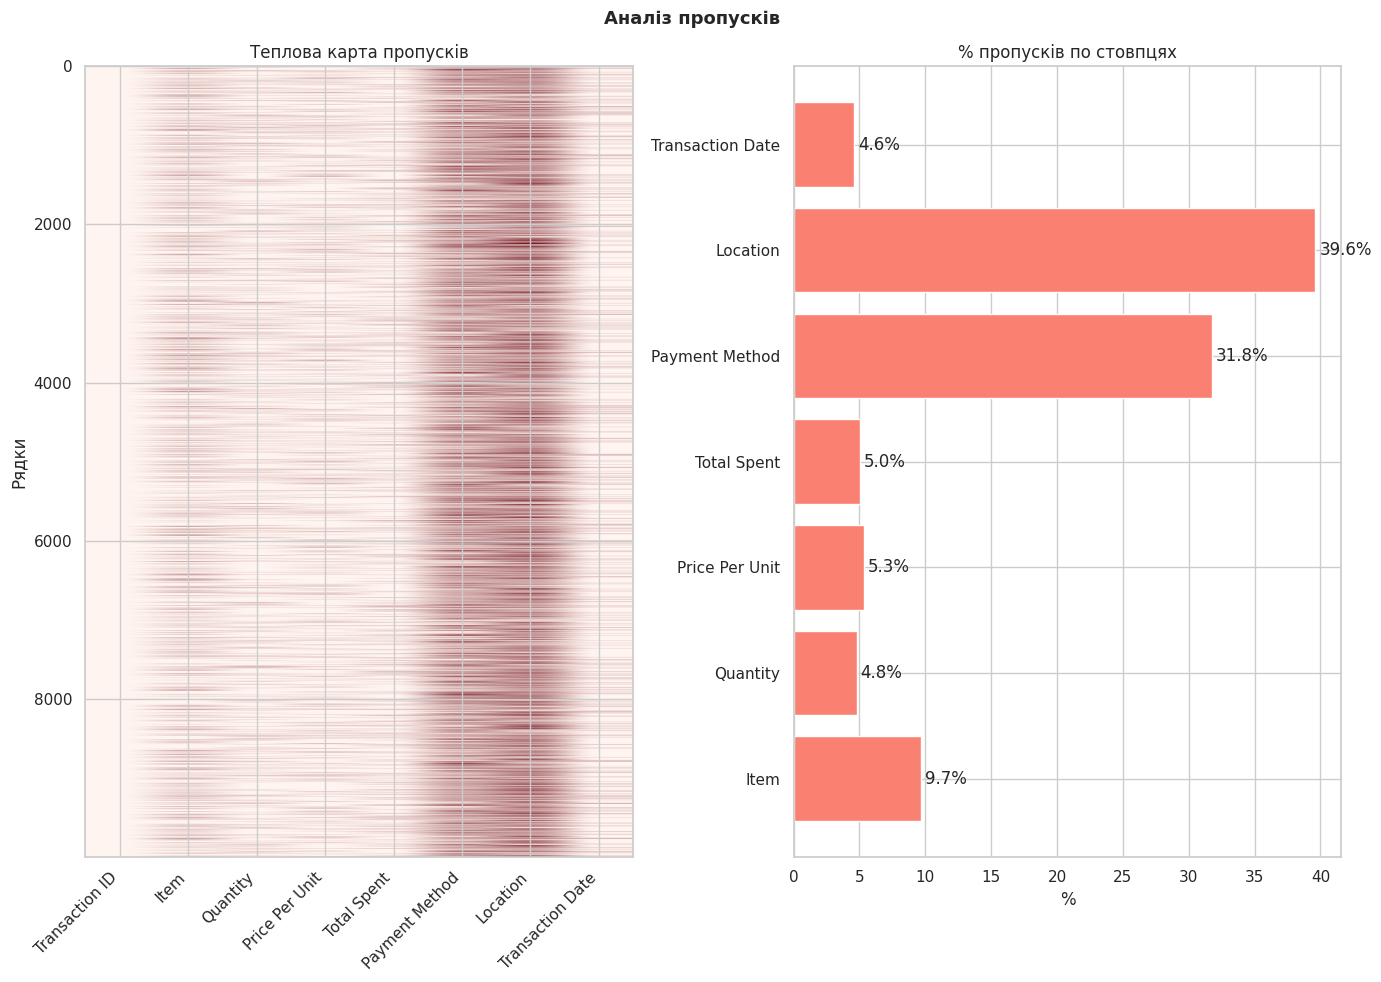

In [11]:
# Крок 4: візуалізація пропусків

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
fig.suptitle('Аналіз пропусків', fontsize=13, fontweight='bold')

# Графік 1: Heatmap пропусків
axes[0].imshow(df.isnull(), aspect='auto', cmap='Reds')
axes[0].set_title('Теплова карта пропусків')
axes[0].set_xticks(range(len(df.columns)))
axes[0].set_xticklabels(df.columns, rotation=45, ha='right')
axes[0].set_ylabel('Рядки')

# Графік 2: Horizontal bar chart — % пропусків по колонках
missing_pct_filtered = missing_df[missing_df['Пропусків'] > 0]['%']
axes[1].barh(missing_pct_filtered.index, missing_pct_filtered.values, color='salmon')
axes[1].set_title('% пропусків по стовпцях')
axes[1].set_xlabel('%')
for i, v in enumerate(missing_pct_filtered.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

---
# ЧАСТИНА 2 — Очищення даних

---

## Підготовка: перейменування колонок

Перейменуйте колонки: приберіть пробіли і зробіть назви у форматі `snake_case`.

| Стара назва | Нова назва |
|-------------|------------|
| `Transaction ID` | `transaction_id` |
| `Item` | `item` |
| `Quantity` | `quantity` |
| `Price Per Unit` | `price_per_unit` |
| `Total Spent` | `total_spent` |
| `Payment Method` | `payment_method` |
| `Location` | `location` |
| `Transaction Date` | `transaction_date` |

In [12]:
# Крок 1: прибрати пробіли з назв
df.columns = df.columns.str.strip()

# Крок 2: перейменувати
df = df.rename(columns={
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_unit',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'
})

print('Нові назви колонок:', list(df.columns))
#print('Нові назви колонок:', list(df.columns))

Нові назви колонок: ['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


## Task 2.1 — Обробка пропусків у категорійних колонках

**Стратегії:**

| Колонка | Стратегія |
|---------|----------|
| `transaction_id` | Видалити рядок |
| `item` | По ціні зі словника (якщо є price) → інакше мода |
| `payment_method` | `'Unknown'` — рекомендовано; або мода (варіант Б) |
| `location` | `'Unknown'` — рекомендовано; або мода (варіант Б) |

**Підказки:**
- `df.dropna(subset=[...])` — видалити рядки де NaN у вказаних колонках
- `df['col'].fillna('Unknown')` — заповнити рядком
- Словник і мода для item — виконуються у Task 2.2 після конвертації числових типів

In [13]:
#до кожнох ціни список значень, формат ключ = списку якщо значення 1 береш, якщо більше береш рандомно.
# transaction_id: видалити рядки де NaN
before = len(df)
# ВАШ КОД ТУТ
print(f'Видалено рядків без transaction_id: {before - len(df)}')


# payment_method: заповнити 'Unknown'
df['payment_method'].fillna('Unknown', inplace=True)

# location: заповнити 'Unknown'
df['location'].fillna('Unknown', inplace=True)

# item: зберігаємо моду
mode_item = df['item'].mode()[0]
#print(f'Зберегли mode_item = "{mode_item}" для резервного заповнення')


Видалено рядків без transaction_id: 0


In [14]:
df.location.unique()
df.payment_method.unique()

array(['Credit Card', 'Cash', 'Unknown', 'Digital Wallet'], dtype=object)

In [15]:
df.location.unique()

array(['Takeaway', 'In-store', 'Unknown'], dtype=object)

## Task 2.2 — Конвертація типів і заповнення item / price / quantity

**Порядок дій:**
1. Конвертувати числові типи (`errors='coerce'`)
2. Побудувати словник `ITEM_PRICE` кодом: `item → мода ціни` з даних
3. **Ситуація 1:** item = NaN, price є → знайти item зі зворотного словника
4. **Ситуація 2:** item є, price = NaN → знайти price зі словника
5. **Ситуація 3:** обидва NaN → item = мода, price = по item
6. **quantity:** якщо є price і total → `qty = total / price`; інакше медіана по товару
7. Відновити `total_spent = qty × price`, перевірити збіг

**Підказки:**
```python
# Побудова словника з даних
df.groupby('item')['price_per_unit'].agg(lambda x: x.mode()[0]).to_dict()
# Зворотний словник
{round(v,2): k for k, v in ITEM_PRICE.items()}
# Медіана по групі
df.groupby('item')['quantity'].transform('median')
```

In [16]:

# Конвертація числових колонок (errors='coerce' → некоректне стає NaN)

df['quantity']         = pd.to_numeric(df['quantity'], errors='coerce')
df['price_per_unit']   = pd.to_numeric(df['price_per_unit'], errors='coerce')
df['total_spent']      = pd.to_numeric(df['total_spent'], errors='coerce')
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

print('Типи після конвертації:')
print(df.dtypes)

Типи після конвертації:
transaction_id              object
item                        object
quantity                   float64
price_per_unit             float64
total_spent                float64
payment_method              object
location                    object
transaction_date    datetime64[ns]
dtype: object


In [78]:
# Крок 0: будуємо словник ITEM_PRICE з даних (item → мода ціни)
# ВАШ КОД ТУТ
item_price = df.groupby('item')['price_per_unit'].agg(lambda x: x.mode()[0]).to_dict()
print(item_price)
# Зворотний словник: ціна → товар
# ВАШ КОД ТУТ
price_item = {}
for key, value in item_price.items():
    if value not in price_item.keys():
        price_item.setdefault(value, []) # значення в ключ, ключ в пустий лист записати
        price_item[value].append(key)#записуємо проходимо по
        print(key, value)
    else:
        price_item[value].append(key)
        print(key, value)
print(price_item)
# зворотній словник наш
print(pd.Series(price_item).sort_index())

{'Cake': 3.0, 'Coffee': 2.0, 'Cookie': 1.0, 'Juice': 3.0, 'Salad': 5.0, 'Sandwich': 4.0, 'Smoothie': 4.0, 'Tea': 1.5}
Cake 3.0
Coffee 2.0
Cookie 1.0
Juice 3.0
Salad 5.0
Sandwich 4.0
Smoothie 4.0
Tea 1.5
{3.0: ['Cake', 'Juice'], 2.0: ['Coffee'], 1.0: ['Cookie'], 5.0: ['Salad'], 4.0: ['Sandwich', 'Smoothie'], 1.5: ['Tea']}
1.0                [Cookie]
1.5                   [Tea]
2.0                [Coffee]
3.0           [Cake, Juice]
4.0    [Sandwich, Smoothie]
5.0                 [Salad]
dtype: object


In [18]:
import numpy as np
RANDOM_STATY = 42
np.random.default_rng(RANDOM_STATY)

price = 5
rnd_item = np.random.choice(price_item[price])
print(rnd_item)
print(price)

Salad
5


In [19]:
df[df["item"].isna() & df["price_per_unit"].isna()].shape[0] # перевірка на 2 значення для розуміння кількісті відносно заг кількості

54

In [20]:
df[df["item"].isna() & df["price_per_unit"].isna()& df["quantity"].isna()].shape[0] # перевірка на 3 значення відносно заг кількості

3

In [21]:
df[df["item"].isna() & df["price_per_unit"].isna()].index[1]

np.int64(151)

In [23]:
# Ситуація 1: item = NaN, price є → знаходимо item по ціні
mask1 = df["item"].isna() & df["price_per_unit"].notna()

# заповнення
df.loc[mask1, "item"] = df.loc[mask1, "price_per_unit"].apply(
    lambda price: np.random.choice(price_item[price]))

df["item"].isna().sum()

np.int64(54)

In [24]:
# Ситуація 2: item є, price = NaN → знаходимо ціну по товару
mask2 = df["item"].notna() & df['price_per_unit'].isna()
df.loc[mask2, 'price_per_unit'] = df.loc[mask2, 'item'].map(item_price)

df['price_per_unit'].isna().sum()
# Підказка: .map(ITEM_PRICE)
#print(f'Ситуація 2 (є item → price): {mask2.sum()} рядків')

np.int64(54)

In [25]:
print("Залишилось NaN в item:", df["item"].isna().sum())
print("Залишилось NaN в price_per_unit:", df["price_per_unit"].isna().sum())

Залишилось NaN в item: 54
Залишилось NaN в price_per_unit: 54


In [26]:
# Заповнення quantity
# Варіант А: є price і total_spent → qty = total / price
mask_qty = df["quantity"].isna() & df["price_per_unit"].notna() # ВАШ КОД ТУТ  (quantity isna AND price notna AND total notna)
df.loc[mask_qty, 'quantity'] = (df.loc[mask_qty, "total_spent"] / df.loc[mask_qty, "price_per_unit"]).round(2)# ВАШ КОД ТУТ
# Підказка: (total_spent / price_per_unit).round()
print(f'quantity відновлено через total/price_pre_unit: {mask_qty.sum()} рядків')

quantity відновлено через total/price_pre_unit: 476 рядків


In [27]:
# Ситуація 3: item і price = NaN, але total_spent і quantity відомі
mask3 = df["item"].isna() & df["price_per_unit"].isna() & df["total_spent"].notna() & df["quantity"].notna()
print(mask3.sum())
df.loc[mask3, "price_per_unit"] = (df.loc[mask3, "total_spent"] / df.loc[mask3, "quantity"]).round(2)

df.loc[mask3, "item"] = df.loc[mask3, "price_per_unit"].apply(
    lambda price: np.random.choice(price_item[price]) if price in price_item else np.nan
)

print(f'Залишилось NaN в item: {df["item"].isna().sum()}')
print(f'Залишилось NaN в price_per_unit: {df["price_per_unit"].isna().sum()}')

48
Залишилось NaN в item: 6
Залишилось NaN в price_per_unit: 6


In [28]:
# total_spent NaN, є new quantity і price_per_unit
mask_total = df["total_spent"].isna() & df["quantity"].notna() & df["price_per_unit"].notna()
df.loc[mask_total, "total_spent"] = df.loc[mask_total, "quantity"] * df.loc[mask_total, "price_per_unit"]

# price_per_unit NaN, є new total_spent і new quantity
mask_price = df["price_per_unit"].isna() & df["total_spent"].notna() & df["quantity"].notna()
df.loc[mask_price, "price_per_unit"] = (df.loc[mask_price, "total_spent"] / df.loc[mask_price, "quantity"]).round(2)

In [29]:
print(df.isna().sum())

transaction_id        0
item                  6
quantity             23
price_per_unit        6
total_spent          23
payment_method        0
location              0
transaction_date    460
dtype: int64


In [30]:
#df.loc[mask_total_spent]

In [31]:
mask_total_spent = (df.quantity * df.price_per_unit != df.total_spent)
print(f"Uncorrect rows total_spent: {mask_total_spent.sum()}")

Uncorrect rows total_spent: 26


In [32]:
print(df.isna().sum())

transaction_id        0
item                  6
quantity             23
price_per_unit        6
total_spent          23
payment_method        0
location              0
transaction_date    460
dtype: int64


In [33]:
df.item.isna().sum()

np.int64(6)

In [34]:
diff = (df["quantity"] * df["price_per_unit"] - df["total_spent"]).abs()
print("Максимальна розбіжність:", diff.max())
print("Кількість рядків з розбіжністю > 0.01:", (diff > 0.01).sum())

Максимальна розбіжність: 0.0
Кількість рядків з розбіжністю > 0.01: 0


In [35]:
test_prices = df.loc[df["item"].isna(), "price_per_unit"]
print(test_prices.unique())
print(list(price_item.keys()))

[nan]
[3.0, 2.0, 1.0, 5.0, 4.0, 1.5]


In [36]:
mask_diff = (df["quantity"] * df["price_per_unit"] - df["total_spent"]).abs() > 0.01
df.loc[mask_diff, ["quantity", "price_per_unit", "total_spent"]]


,quantity,price_per_unit,total_spent


In [37]:
df.loc[df["item"].isna(), ["item", "price_per_unit", "total_spent", "quantity"]]

,item,price_per_unit,total_spent,quantity
1761,NaN,NaN,NaN,4.0
2289,NaN,NaN,NaN,4.0
3779,NaN,NaN,25.0,NaN
4152,NaN,NaN,NaN,2.0
7597,NaN,NaN,9.0,NaN
9819,NaN,NaN,20.0,NaN


In [38]:
df.loc[df["quantity"].isna(), ["item", "price_per_unit", "total_spent", "quantity"]]

,item,price_per_unit,total_spent,quantity
236,Salad,5.0,NaN,NaN
278,Juice,3.0,NaN,NaN
641,Juice,3.0,NaN,NaN
738,Sandwich,4.0,NaN,NaN
2796,Cake,3.0,NaN,NaN
3203,Smoothie,4.0,NaN,NaN
3224,Coffee,2.0,NaN,NaN
3401,Tea,1.5,NaN,NaN
3779,NaN,NaN,25.0,NaN
4257,Coffee,2.0,NaN,NaN


In [39]:
# Для рядків де є item і price_per_unit, але немає quantity і total_spent
# Я вирішила заповнити медіаною *(quantity)цю невелику кількість данних 20 позицій, що становить 0,2% просто щоб не видаляти хоча можна і просто видалити
# потім я підставлю цей новий показник
mask_qty_only = df["item"].notna() & df["price_per_unit"].notna() & df["quantity"].isna()
median_qty = df["quantity"].median()
df.loc[mask_qty_only, "quantity"] = median_qty
df.loc[mask_qty_only, "total_spent"] = df.loc[mask_qty_only, "quantity"] * df.loc[mask_qty_only, "price_per_unit"]
mask_qty_only.sum()
print(f'Заповнено quantity медіаною ({median_qty}) для {mask_qty_only.sum()} рядків')

Заповнено quantity медіаною (3.0) для 20 рядків


### Перевірка total_spent і рішення про розбіжності

Після відновлення порівняйте `total_spent` з `quantity × price_per_unit`.

Якщо є розбіжності — що з ними робити?

| Ситуація | Рішення |
|----------|---------|
| `total_spent` відновлювався з NaN | Перерахований вже правильний — залишити |
| `qty` або `price` відновлювались (мода/словник) | Перерахований надійніший — **перезаписати** |
| Всі поля були в оригіналі, але не збігаються | Помилка вводу — **перезаписати** |

У нашому проєкті — **перезаписуємо** скрізь де є розбіжність,
бо ціни зі словника надійніші за оригінал.

In [40]:
 #Крок 1: порахувати очікуване значення для кожного рядка
df['_expected'] = df["quantity"]*df["price_per_unit"]# ВАШ КОД ТУТ  (qty × price, round(2))
df['_expected'].head()
# Крок 2: знайти рядки де total_spent не збігається з _expected
mask_mismatch = (df['total_spent'].round(2) !=
             (df['quantity'].astype(float) * df['price_per_unit']).round(2))
n_mismatch = mask_mismatch.sum()
print(f'Збігів:       {len(df) - n_mismatch} / {len(df)}')
print(f'Розбіжностей: {n_mismatch}')
# Крок 3: показати перші 5 розбіжностей
print('\nПерші 5 (до виправлення):')
print(df.loc[mask_mismatch,['item','quantity','price_per_unit','total_spent','_expected']].head())
# Крок 4- такі розбіжності не можуть бути перезаписані там не відомо назва товару та його не можливо
# : ПЕРЕЗАПИСАТИ total_spent перерахованим значенням
    # ВАШ КОД ТУТ
print(f'\n→ total_spent перезаписано для {n_mismatch} рядків')
df.drop(columns=['_expected'], inplace=True)# видалено expectetd

# Крок 5: фінальна перевірка — розбіжностей має бути 0
still_bad = (df['total_spent'].round(2) !=
             (df['quantity'].astype(float) * df['price_per_unit']).round(2)).sum()
print(f'\nФінальна перевірка: {still_bad} розбіжностей залишилось')
#рядки 6 - значень без коректних item/price/quantity/total_spent неможливо восстановити , тому видаляємо їх остаточно.
# видаляємо також рядки без transaction_date, оскільки дата важлива і не може бути логічно відновлена з інших полів.

#Маска для цих рядків
mask_drop = ( df["item"].isna() | df["quantity"].isna() | df["price_per_unit"].isna() | df["total_spent"].isna() | df["transaction_date"].isna() )

#Зберігаємо індекси та самі видалені рядки для архіву
dropped_indices = df.index[mask_drop].tolist()
dropped_rows = df.loc[mask_drop].copy()       # fhüsd
before = len(df)
print(f'Рядків для видалення: {len(dropped_indices)}')
print(f'Це {len(dropped_indices) / len(df) * 100:.2f}% від датасету')
# Видалити рядки без дати
#
# ВАШ КОД ТУТ
#print(f'Видалено рядків без дати: {before - len(df)}')

Збігів:       9994 / 10000
Розбіжностей: 6

Перші 5 (до виправлення):
     item  quantity  price_per_unit  total_spent  _expected
1761  NaN       4.0             NaN          NaN        NaN
2289  NaN       4.0             NaN          NaN        NaN
3779  NaN       NaN             NaN         25.0        NaN
4152  NaN       2.0             NaN          NaN        NaN
7597  NaN       NaN             NaN          9.0        NaN

→ total_spent перезаписано для 6 рядків

Фінальна перевірка: 6 розбіжностей залишилось
Рядків для видалення: 466
Це 4.66% від датасету


In [41]:
#Крок 6  видалення - значень без коректних item/price/quantity/total_spent неможливо восстановити , тому видаляємо їх остаточно.
# видаляємо також рядки без transaction_date, оскільки дата важлива і не може бути логічно відновлена з інших полів.

#Маска для цих рядків
mask_drop = ( df["item"].isna() | df["quantity"].isna() | df["price_per_unit"].isna() | df["total_spent"].isna() | df["transaction_date"].isna() )

#Зберігаємо індекси та самі видалені рядки для архіву
dropped_indices = df.index[mask_drop].tolist()
dropped_rows = df.loc[mask_drop].copy()       # fhüsd
before = len(df)
print(f'Рядків для видалення: {len(dropped_indices)}')
print(f'Це {len(dropped_indices) / len(df) * 100:.2f}% від датасету')
# Видалити рядки без дати та іш з маски дроп
df = df.drop(index=dropped_indices)
# ВАШ КОД ТУТ
print(f'Видалено рядків без дати: {before - len(df)}')

Рядків для видалення: 466
Це 4.66% від датасету
Видалено рядків без дати: 466


## Task 2.3 — Стандартизація тексту

Приведіть `item`, `payment_method`, `location` до єдиного формату:
- Приберіть зайві пробіли (`.str.strip()`)
- Кожне слово з великої літери (`.str.title()`)

In [42]:
for col in ['item', 'payment_method', 'location']:
    df[col] = df[col].str.strip().str.title()

print('Унікальні payment_method:', sorted(df['payment_method'].unique()))
print('Унікальні location:',       sorted(df['location'].unique()))

Унікальні payment_method: ['Cash', 'Credit Card', 'Digital Wallet', 'Unknown']
Унікальні location: ['In-Store', 'Takeaway', 'Unknown']


## Task 2.4 — Feature Engineering

З колонки `transaction_date` витягніть нові ознаки:

| Нова колонка | Що містить | Підказка |
|-------------|------------|----------|
| `year` | Рік (число) | `.dt.year` |
| `month` | Місяць (число 1–12) | `.dt.month` |
| `month_name` | Назва місяця рядком | `.dt.strftime('%B')` |
| `weekday` | Назва дня тижня | `.dt.day_name()` |
| `is_weekend` | True якщо сб/нд | `.isin(['Saturday', 'Sunday'])` |

In [43]:
df['year']       = df['transaction_date'].dt.year
df['month']      = df['transaction_date'].dt.month
df['month_name'] = df['transaction_date'].dt.strftime('%B').round()
df['weekday']    = df['transaction_date'].dt.day_name()
df['week']       = df['transaction_date'].dt.isocalendar().week.astype('Int64')
df['is_weekend'] = df["week"].isin(["Saturday", "Sunday"])

# Перевірка логічності
df = df[df['quantity'] > 0]
df = df[df['total_spent'] > 0]

print(f'✓ Фінальний датасет: {df.shape}')
print('\nПерші рядки з новими колонками:')
df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'is_weekend']].head(12)
print(df["weekday"].unique())

✓ Фінальний датасет: (9534, 14)

Перші рядки з новими колонками:
['Friday' 'Tuesday' 'Wednesday' 'Thursday' 'Sunday' 'Saturday' 'Monday']


In [44]:
# Зберегти чистий файл
df_tableau = df.copy()
df_tableau['transaction_date'] = df_tableau['transaction_date'].dt.strftime('%Y-%m-%d')
df_tableau['is_weekend'] = df_tableau['is_weekend'].map({True: 'Yes', False: 'No'})
df_tableau.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')
print(f'✓ Збережено: {FILE_OUT} — готовий для Tableau!')

✓ Збережено: cafe_sales_clean_clean_v2.csv — готовий для Tableau!


In [45]:
print(df.isna().sum())

transaction_id      0
item                0
quantity            0
price_per_unit      0
total_spent         0
payment_method      0
location            0
transaction_date    0
year                0
month               0
month_name          0
weekday             0
week                0
is_weekend          0
dtype: int64


---
# ЧАСТИНА 3 — EDA

---

## Task 3.1 — Топ товари

**Що потрібно:**
1. Топ-5 товарів за `quantity` (кількість)
2. Топ-5 товарів за `total_spent` (виторг)
3. Два bar chart поруч — один для кожного топу

**Підказка:** `df.groupby('item')['quantity'].sum().sort_values(ascending=False).head(5)`

In [46]:
# Топ-5 за кількістю
top_qty = df.groupby("item")["quantity"].sum().sort_values(ascending=False).head(5)

# Топ-5 за виторгом
top_rev = df.groupby("item")["total_spent"].sum().sort_values(ascending=False).head(5)


print('Топ-5 за кількістю:')
print(top_qty.to_string())
print('\nТоп-5 за виторгом:')
print(top_rev.round(2).to_string())

Топ-5 за кількістю:
item
Coffee      3781.0
Juice       3719.0
Salad       3650.0
Cake        3629.0
Sandwich    3586.0

Топ-5 за виторгом:
item
Salad       18250.0
Sandwich    14344.0
Smoothie    14248.0
Juice       11157.0
Cake        10887.0


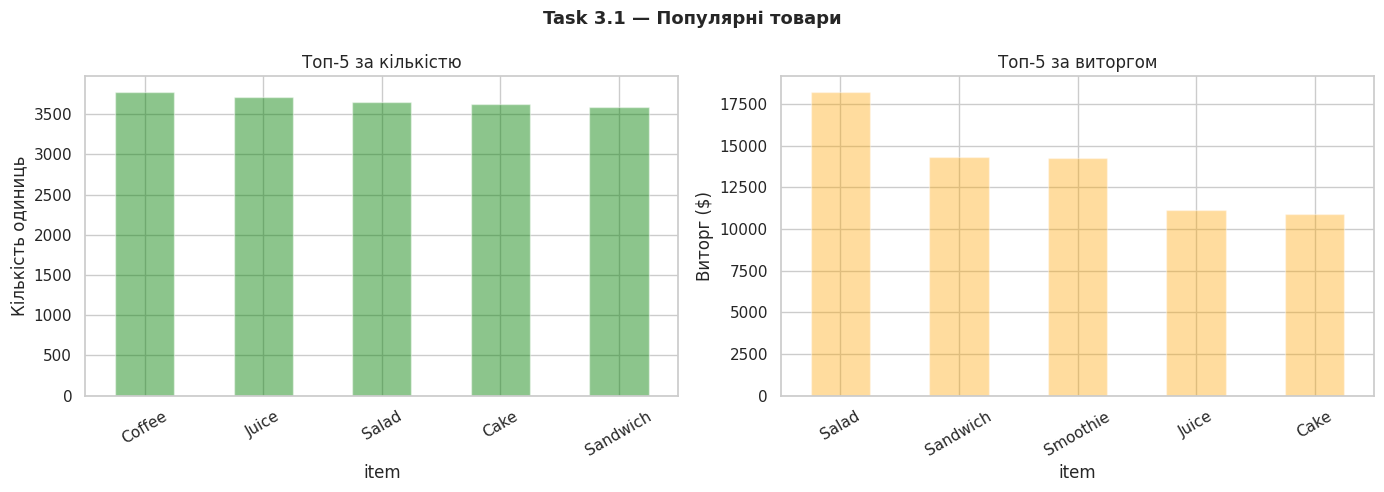

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 3.1 — Популярні товари', fontsize=13, fontweight='bold')

# Графік 1: топ за кількістю
# ВАШ КОД ТУТ
top_qty.plot(kind='bar', ax=axes[0], color = "green", alpha = 0.45)
axes[0].set_title('Топ-5 за кількістю')
axes[0].set_ylabel('Кількість одиниць')
axes[0].tick_params(axis='x', rotation=30)

# Графік 2: топ за виторгом
# ВАШ КОД ТУТ
top_rev.plot(kind='bar', ax=axes[1], color = "orange",alpha = 0.38)
axes[1].set_title('Топ-5 за виторгом')
axes[1].set_ylabel('Виторг ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('part3_task31.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Висновок до Task 3.1
*(Що помітили? Чи збігаються топи за кількістю та виторгом?)*

- ...то5 виглядає за кількістю майже однаково, це динамічні показники, тому топ 5 може змінюватися кожну неділю.
Топ 5 за виторгом виділяє чітко 3 найкращих позицій. Для зміцнення інших може бути доціільно проводити акції поєднуючи продаваніші товари з менш продаванішими.

## Task 3.2 — Payment Method та Location

**Що потрібно:**
1. Загальний виторг по `payment_method` — pie chart
2. Загальний виторг по `location` — bar chart

**Підказка:** `df.groupby('payment_method')['total_spent'].sum()`

In [48]:
rev_pay = df.groupby("payment_method")["total_spent"].sum()
rev_loc = df.groupby("location")["total_spent"].sum()

print('Виторг по оплаті:')
print(rev_pay.round(2).to_string())
print('\nВиторг по локації:')
print(rev_loc.round(2).to_string())

Виторг по оплаті:
payment_method
Cash              19570.0
Credit Card       19499.5
Digital Wallet    19574.5
Unknown           26403.0

Виторг по локації:
location
In-Store    25928.0
Takeaway    25446.5
Unknown     33672.5


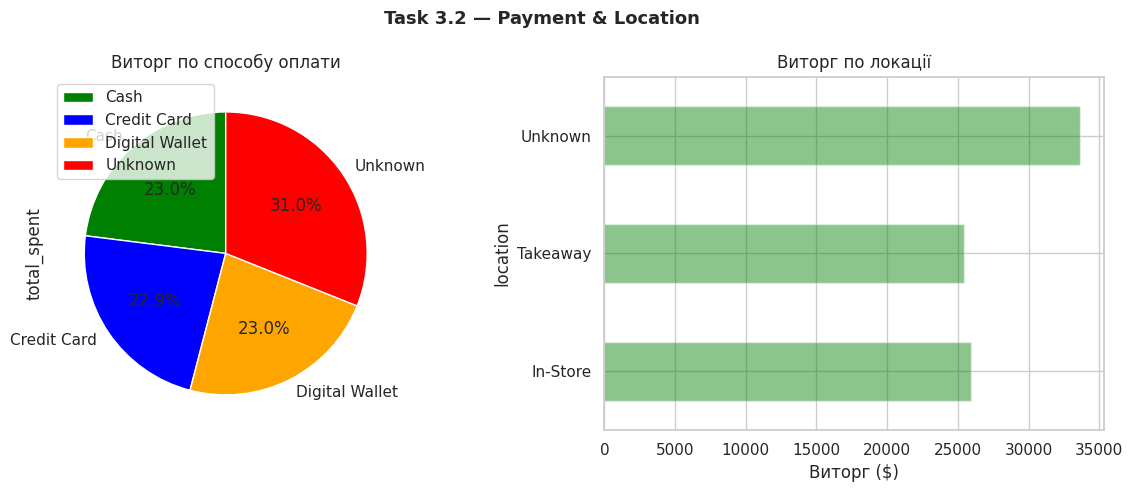

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 3.2 — Payment & Location', fontsize=13, fontweight='bold')

# Pie chart — payment_method
# Підказка: axes[0].pie(rev_pay, labels=rev_pay.index, autopct='%1.1f%%', startangle=90, ...)
# ВАШ КОД ТУТ
rev_pay.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90, colors =["green", "blue", "orange", "red"])
axes[0].set_title('Виторг по способу оплати')
axes[0].legend(loc='upper left')

# Bar chart — location
# ВАШ КОД ТУТ
rev_loc.plot(kind='barh', ax=axes[1], color = "green", alpha = 0.45)
axes[1].set_title('Виторг по локації')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_xlabel('Виторг ($)')

plt.tight_layout()
plt.savefig('part3_task32.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Висновок до Task 3.2

- Який спосіб оплати домінує: ___відповідно до даних домінуючого способу оплати немає. Значення динамічне, може змінюватися швидко.
- In-store чи Takeaway більше: ___за локацією також немає домінуючого критерію, не достатньо даних для висновків, окрім опису фактів.

## Task 3.3 — Часові тренди

**Що потрібно:**
1. Щоденний виторг — лінійний графік
2. Щомісячний виторг — bar chart
3. Середній виторг по днях тижня — bar chart (червоний = вихідні)

**Підказки:**
- `df.groupby('transaction_date')['total_spent'].sum().reset_index()`
- `df.groupby('weekday')['total_spent'].mean().reindex(dow_order)`
- Правильний порядок: `['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']`

In [75]:
# Щоденний виторг
daily_rev = df.groupby('transaction_date')['total_spent'].sum().reset_index()
daily_rev.set_index('transaction_date', inplace=True)

# Щомісячний виторг
monthly_rev = df.groupby(['year', 'month'])['total_spent'].sum().reset_index()
monthly_rev.set_index(['year', 'month'], inplace=True)

# По днях тижня (середнє)
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_dow = df.groupby('weekday')['total_spent'].mean().reindex(dow_order)


print(f'Найкращий день: {avg_dow.idxmax()}')
print(f'Найгірший день: {avg_dow.idxmin()}')

Найкращий день: Tuesday
Найгірший день: Wednesday


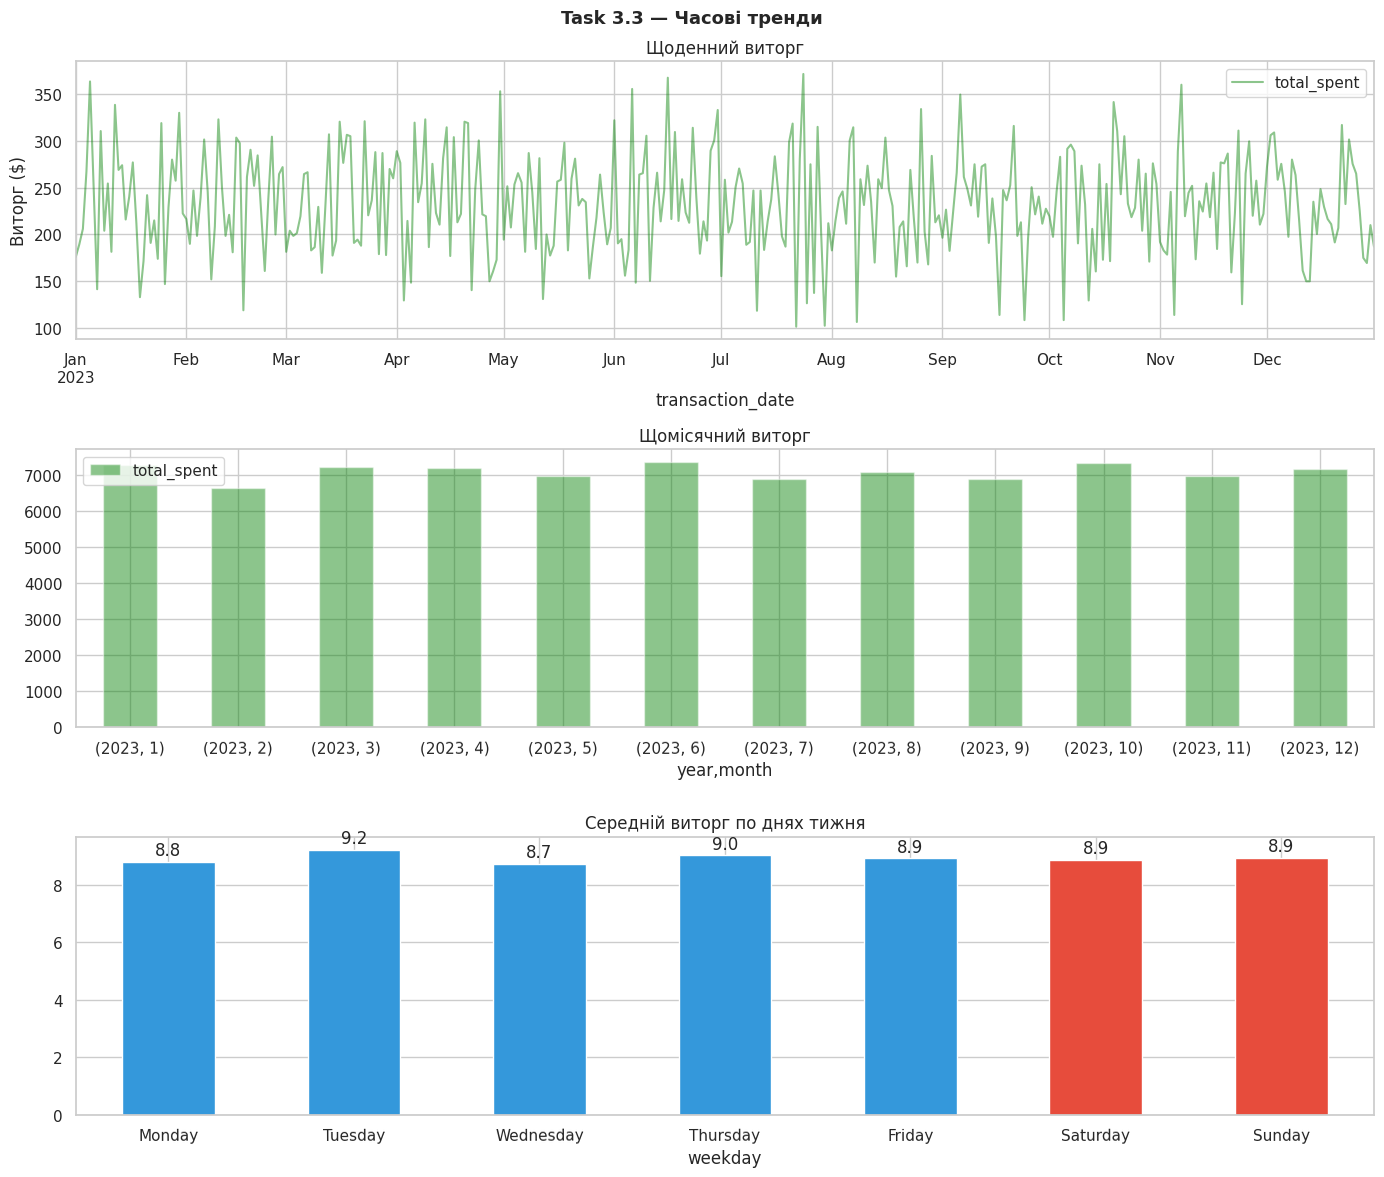

Місяць з найнижчим виторгом: (np.int32(2023), np.int32(2)), виторг: 6644.00


In [51]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Task 3.3 — Часові тренди', fontsize=13, fontweight='bold')

# Графік 1: щоденний лінійний
# ВАШ КОД ТУТ
daily_rev.plot(kind='line', ax=axes[0], color = "green", alpha = 0.45)
axes[0].set_title('Щоденний виторг')
axes[0].set_ylabel('Виторг ($)')

# Графік 2: щомісячний бар
# Підказка: зробіть колонку label = перші 3 літери місяця + рік
# ВАШ КОД ТУТ
monthly_rev.plot(kind='bar', ax=axes[1], color = "green", alpha = 0.45, rot= 0.33)
axes[1].set_title('Щомісячний виторг')

# Графік 3: по днях тижня (вихідні = червоні, будні = сині)
colors_dow = ['#E74C3C' if d in ['Saturday','Sunday'] else '#3498DB' for d in avg_dow.index]
axes[2].set_title('Середній виторг по днях тижня')
axes[2].tick_params(axis='x', rotation=30)
for i, v in enumerate(avg_dow.values):
    axes[2].text(i, v + 0.1, f'{v:.1f}', ha='center', va='bottom')
avg_dow.plot(kind='bar', ax=axes[2], color=colors_dow, rot= 0.33)
# ВАШ КОД ТУТ


plt.tight_layout()
plt.savefig('part3_task33.png', dpi=130, bbox_inches='tight')
plt.show()

# Знайти місяць з найнижчим виторгом
# Знайти місяць з найнижчим виторгом
worst_month = monthly_rev['total_spent'].idxmin()
worst_value = monthly_rev['total_spent'].min()
print(f'Місяць з найнижчим виторгом: {worst_month}, виторг: {worst_value:.2f}')



In [77]:
#вивела значення щоб побачити цифрою це відхилення протягом року.
deviation_from_mean = monthly_rev['total_spent'].std() / monthly_rev['total_spent'].mean()
print(f'Коефіцієнт варіації: {deviation_from_mean*100:.2f}%')

Коефіцієнт варіації: 3.05%


### ✏️ Висновок до Task 3.3

- Найкращий день тижня: _Поневілок
- Найгірший місяць: _лютий 2023 року
- Є сезонний тренд? _сезонних трендів немає, стандартне відхилення відрізняється від середнього значення вього на 3,5 відсотки

## Task 3.4 — Виявлення викидів

**Що потрібно:**
1. Побудувати boxplot для `quantity` і `total_spent`
2. Розрахувати межі викидів методом IQR
3. Порахувати кількість викидів
4. Прийняти рішення: видалити, залишити або кепувати

**Формули IQR:**
```
IQR = Q3 - Q1
Нижня межа = Q1 - 1.5 × IQR
Верхня межа = Q3 + 1.5 × IQR
```

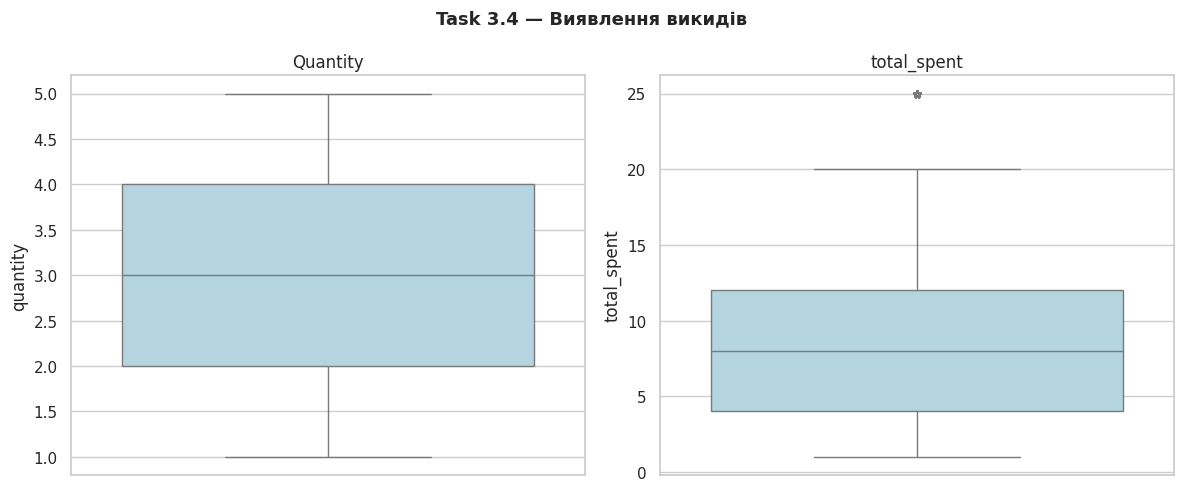

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 3.4 — Виявлення викидів', fontsize=13, fontweight='bold')

# Boxplot для quantity
sns.boxplot(
            y=df['quantity'].astype(float),
            ax=axes[0], color='lightblue', flierprops=dict(marker='*',color="red"))

axes[0].set_title('Quantity')

# Boxplot для total_spent
# ВАШ КОД ТУТ
sns.boxplot(
            y=df['total_spent'].astype(float),
            ax=axes[1], color='lightblue', flierprops=dict(marker='*',color="red"))
axes[1].set_title('total_spent')

plt.tight_layout()
plt.savefig('part3_task34.png', dpi=130, bbox_inches='tight')
plt.show()

In [87]:
# Кількісний аналіз викидів методом IQR
 # ВАШ КОД ТУТ  (25-й перцентиль total_spent)
Q1  = df['total_spent'].quantile(0.25)
Q3  = df['total_spent'].quantile(0.75)
# ВАШ КОД ТУТ  (75-й перцентиль)
IQR = Q3-Q1

low  = Q1-1.5*IQR  # ВАШ КОД ТУТ  (нижня межа)
high = Q3+1.5*IQR  # ВАШ КОД ТУТ  (верхня межа)
# ВАШ КОД ТУТ  (кількість значень поза межами)
n_outliers = (df.total_spent > high).sum() | (df.total_spent < low).sum()


print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'Нормальний діапазон: [{low:.2f}, {high:.2f}]')
print(f'Кількість викидів: {n_outliers}')

Q1=4.00, Q3=12.00, IQR=8.00
Нормальний діапазон: [-8.00, 24.00]
Кількість викидів: 259


### ✏️ Рішення щодо викидів
*(Напишіть своє рішення та обгрунтування)*

**Рішення:** залишити / видалити / кепувати (потрібне підкресліть)

**Обгрунтування:** ...

## Task 3.5 — Кореляційний аналіз

**Що потрібно:**
1. Порахувати кореляційну матрицю для `quantity`, `price_per_unit`, `total_spent`
2. Побудувати heatmap
3. Інтерпретувати результати

**Підказка:** `df[cols].astype(float).corr()`

Кореляційна матриця:
                quantity  price_per_unit  total_spent
quantity           1.000           0.007        0.704
price_per_unit     0.007           1.000        0.646
total_spent        0.704           0.646        1.000


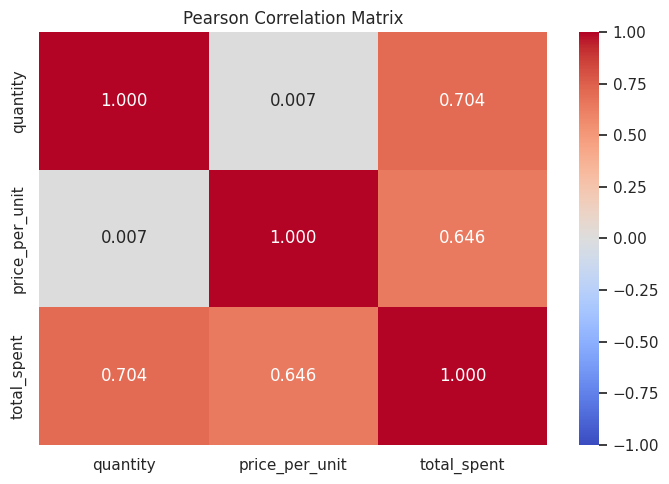

In [92]:
corr_cols   = ['quantity', 'price_per_unit', 'total_spent']
corr_matrix = df[corr_cols].astype(float).corr()
print('Кореляційна матриця:')
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 5))

# Heatmap кореляцій
sns.heatmap(corr_matrix,
            fmt='.3f', annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1
            )
# ВАШ КОД ТУТ

ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.savefig('part3_task35.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Інтерпретація кореляцій

| Пара | Значення | Сила | Пояснення |
|------|----------|------|-----------|
| total_spent ↔ quantity | ___ | ___ | ___ |
| total_spent ↔ price_per_unit | ___ | ___ | ___ |
| quantity ↔ price_per_unit | ___ | ___ | ___ |

---
# ЧАСТИНА 4 — Висновки та рекомендації

---

In [ ]:
# Зберіть всі ключові метрики і надрукуйте підсумковий звіт

top_item_rev  = # ВАШ КОД ТУТ  (найприбутковіший товар)
top_item_qty  = # ВАШ КОД ТУТ  (найпопулярніший за кількістю)
top_pay       = # ВАШ КОД ТУТ  (домінуючий спосіб оплати)
top_loc       = # ВАШ КОД ТУТ  (топ локація)
total_revenue = # ВАШ КОД ТУТ
avg_check     = # ВАШ КОД ТУТ

print('=' * 55)
print('  ЗВІТ ДЛЯ ВЛАСНИКА КАФЕ')
print('=' * 55)

# Напишіть свій звіт тут — власними словами!
# ВАШ КОД ТУТ

## ✅ Фінальний чеклист

Поставте ✓ навпроти кожного виконаного пункту:

**Частина 1**
- [ ] Завантажено і оглянуто датасет
- [ ] Знайдено і видалено дублікати
- [ ] Порахована і візуалізована кількість пропусків

**Частина 2**
- [ ] Перейменовано колонки
- [ ] Замінено ERROR/UNKNOWN на NaN
- [ ] Заповнено пропуски payment_method і location
- [ ] Конвертовано типи даних
- [ ] Побудовано словник ITEM_PRICE з даних
- [ ] Оброблено три ситуації item/price
- [ ] Відновлено quantity (через total/price або медіана по товару)
- [ ] Відновлено total_spent, перевірено збіг і перезаписано розбіжності
- [ ] Стандартизовано текст
- [ ] Додано часові ознаки
- [ ] Збережено FILE_OUT

**Частина 3**
- [ ] Task 3.1: топ товари — два бар-чарти
- [ ] Task 3.2: оплата і локація — pie + bar
- [ ] Task 3.3: часові тренди — 3 графіки
- [ ] Task 3.4: boxplot + IQR аналіз
- [ ] Task 3.5: кореляційна матриця + heatmap

**Частина 4**
- [ ] Підсумковий звіт з конкретними числами
- [ ] Мінімум 1 бізнес-рекомендація

---
**🎉 Вітаємо з завершенням проєкту!**